# **Task 3–Bias Detection on Story Premises**
### ***Name:*** Vivan Kushal Heneger
### ***Subject***: Generative AI for Business- CSC8646
### ***Student_ID:*** 250469037


### Dataset: premises.csv (100 story premises)  
### Goal: detect bias signals (themes, characters, gender roles, cultures) and validate using LLM comparison + temperature experiment

## Setup (Reproducibility + Libraries)

In [24]:
import os, re, random, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

random.seed(42)
np.random.seed(42)

pd.set_option("display.max_colwidth", 80)
print("Ready")

Ready


Ensures reproducible outputs and prepares tools for analysis and plotting.

## Drive Mount

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data

In [26]:
CSV_PATH = "/content/drive/MyDrive/DataSet/DL_Dataset/premises.csv"
df_raw = pd.read_csv(CSV_PATH)

first_col = df_raw.columns[0].strip()
premises = []

if len(df_raw) < 100 and len(first_col.split()) > 6:
    premises.append(first_col)
    premises.extend(df_raw.iloc[:, 0].dropna().astype(str).tolist())
else:
    premises = df_raw.iloc[:, 0].dropna().astype(str).tolist()

df = pd.DataFrame({"premise": premises})
df["premise"] = df["premise"].astype(str).str.strip()
df = df[df["premise"] != ""].reset_index(drop=True)

print("Stories:", len(df))
df.head()

Stories: 100


,premise
0,"In a quest for justice, a passionate and idealistic female lawyer of African..."
1,"In 1960s rural southern town, a determined young African American girl faces..."
2,"In 18th century Native American tribe, a young member struggles to balance t..."
3,"In 1970s Detroit, a disillusioned African American former auto executive, ha..."
4,"A young, idealistic African American prosecutor, struggling with the ethical..."


Loads the 100 premises robustly (including the “first premise stored in header” edge case).

## Text Preprocessing

In [27]:
def clean_text(s):
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^a-z0-9\s\-\']", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["premise_clean"] = df["premise"].apply(clean_text)
df[["premise", "premise_clean"]].head()

,premise,premise_clean
0,"In a quest for justice, a passionate and idealistic female lawyer of African...",in a quest for justice a passionate and idealistic female lawyer of african ...
1,"In 1960s rural southern town, a determined young African American girl faces...",in 1960s rural southern town a determined young african american girl faces ...
2,"In 18th century Native American tribe, a young member struggles to balance t...",in 18th century native american tribe a young member struggles to balance tr...
3,"In 1970s Detroit, a disillusioned African American former auto executive, ha...",in 1970s detroit a disillusioned african american former auto executive haun...
4,"A young, idealistic African American prosecutor, struggling with the ethical...",a young idealistic african american prosecutor struggling with the ethical d...


Normalises text for consistent keyword tagging and modelling

## Rule-Based Tags (Gender, Culture, Theme, Role)

In [28]:
MALE_TERMS = {"he","him","his","boy","father","dad","king","prince","brother","son","uncle","man","men"}
FEMALE_TERMS = {"she","her","hers","girl","mother","mom","queen","princess","sister","daughter","aunt","woman","women"}

CULTURE_TERMS = {
    "western": {"london","england","britain","uk","europe","paris","rome","america","canada"},
    "south_asian": {"india","pakistan","bangladesh","sri lanka","nepal","diwali","holi"},
    "east_asian": {"china","japan","korea","tokyo","beijing","seoul"},
    "middle_east": {"arab","iran","iraq","dubai","qatar","saudi"},
    "african": {"africa","nigeria","kenya","ghana","ethiopia"},
    "latin_american": {"mexico","brazil","argentina","peru"},
}

THEME_TERMS = {
    "friendship": {"friend","friends","buddy","kind","help","share","together"},
    "adventure": {"adventure","journey","quest","explore","trek","map"},
    "family": {"family","mother","father","parents","home","sibling"},
    "magic": {"magic","wizard","spell","enchanted","fairy","dragon"},
    "school": {"school","teacher","class","homework"},
    "justice": {"steal","stole","thief","crime","police","judge","trial"},
    "fear": {"scared","fear","fright","monster","nightmare"},
}

LEADERSHIP_TERMS = {"leader","captain","boss","chief","king","queen","commander"}
CARE_TERMS = {"cook","clean","nurse","care","caregiver","babysit","feed","wash","maid"}

def tag_gender(text):
    tokens = set(text.split())
    male = len(tokens.intersection(MALE_TERMS))
    female = len(tokens.intersection(FEMALE_TERMS))
    if male > female and male > 0:
        return "male_coded"
    if female > male and female > 0:
        return "female_coded"
    if male == female and male > 0:
        return "mixed"
    return "unknown"

def tag_culture(text):
    hits = []
    for k, vocab in CULTURE_TERMS.items():
        for term in vocab:
            if term in text:
                hits.append(k)
                break
    if len(hits) == 0:
        return "unspecified"
    if len(hits) == 1:
        return hits[0]
    return "multiple"

def tag_theme(text):
    scores = {}
    for theme, vocab in THEME_TERMS.items():
        scores[theme] = sum(1 for term in vocab if term in text)
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "other"

def tag_roles(text):
    tokens = set(text.split())
    lead = len(tokens.intersection(LEADERSHIP_TERMS))
    care = len(tokens.intersection(CARE_TERMS))
    if lead > care and lead > 0:
        return "leadership"
    if care > lead and care > 0:
        return "caregiving"
    if lead == care and lead > 0:
        return "mixed"
    return "none"

df["gender_tag"] = df["premise_clean"].apply(tag_gender)
df["culture_tag"] = df["premise_clean"].apply(tag_culture)
df["theme_tag"] = df["premise_clean"].apply(tag_theme)
df["role_tag"] = df["premise_clean"].apply(tag_roles)

df.head()

,premise,premise_clean,gender_tag,culture_tag,theme_tag,role_tag
0,"In a quest for justice, a passionate and idealistic female lawyer of African...",in a quest for justice a passionate and idealistic female lawyer of african ...,female_coded,multiple,adventure,none
1,"In 1960s rural southern town, a determined young African American girl faces...",in 1960s rural southern town a determined young african american girl faces ...,female_coded,multiple,school,leadership
2,"In 18th century Native American tribe, a young member struggles to balance t...",in 18th century native american tribe a young member struggles to balance tr...,unknown,western,other,none
3,"In 1970s Detroit, a disillusioned African American former auto executive, ha...",in 1970s detroit a disillusioned african american former auto executive haun...,unknown,multiple,other,none
4,"A young, idealistic African American prosecutor, struggling with the ethical...",a young idealistic african american prosecutor struggling with the ethical d...,unknown,multiple,other,none


Produces transparent baseline labels for bias analysis and later LLM agreement testing.

Results: Distributions + Visuals

In [29]:
def dist_table(col):
    vc = df[col].value_counts(dropna=False)
    pct = (vc / len(df) * 100).round(1)
    return pd.DataFrame({"count": vc, "percent": pct})

display(dist_table("gender_tag"))
display(dist_table("culture_tag"))
display(dist_table("theme_tag"))
display(dist_table("role_tag"))

,count,percent
gender_tag,,
male_coded,40,40.0
unknown,30,30.0
female_coded,24,24.0
mixed,6,6.0


,count,percent
culture_tag,,
unspecified,37,37.0
multiple,21,21.0
western,21,21.0
african,9,9.0
south_asian,5,5.0
east_asian,4,4.0
middle_east,2,2.0
latin_american,1,1.0


,count,percent
theme_tag,,
other,47,47.0
family,18,18.0
friendship,15,15.0
adventure,10,10.0
justice,5,5.0
school,4,4.0
fear,1,1.0


,count,percent
role_tag,,
none,81,81.0
leadership,19,19.0


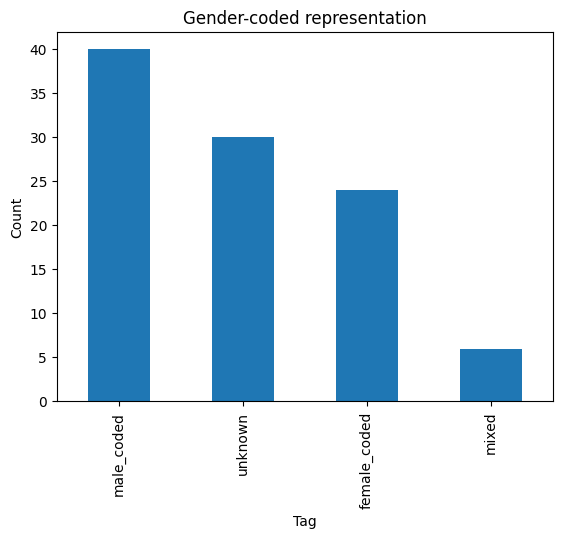

In [30]:
dist_table("gender_tag")["count"].plot(kind="bar")
plt.title("Gender-coded representation")
plt.xlabel("Tag")
plt.ylabel("Count")
plt.show()


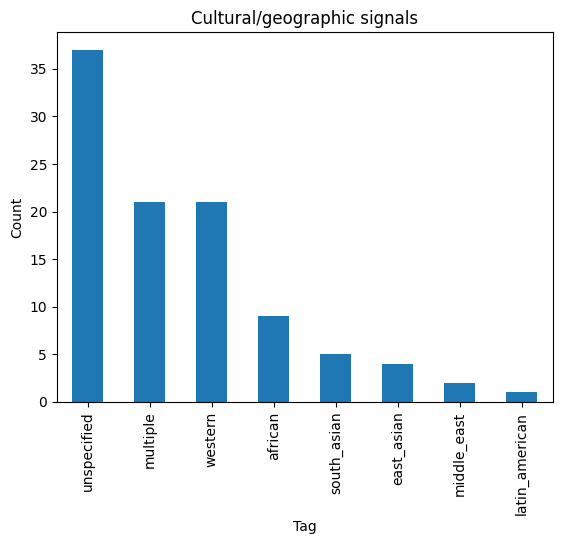

In [31]:
dist_table("culture_tag")["count"].plot(kind="bar")
plt.title("Cultural/geographic signals")
plt.xlabel("Tag")
plt.ylabel("Count")
plt.show()

Gives the core quantitative evidence for bias (counts + percentages + imbalance visuals).

## Cross-tabs (Stereotypes + Diversity)

In [32]:
ct_gender_role = pd.crosstab(df["gender_tag"], df["role_tag"], normalize="index").round(3)
ct_theme_culture = pd.crosstab(df["theme_tag"], df["culture_tag"], normalize="index").round(3)
display(ct_gender_role)
display(ct_theme_culture)

role_tag,leadership,none
gender_tag,,
female_coded,0.083,0.917
male_coded,0.250,0.750
mixed,0.167,0.833
unknown,0.200,0.800


culture_tag,african,east_asian,latin_american,middle_east,multiple,south_asian,unspecified,western
theme_tag,,,,,,,,
adventure,0.100,0.000,0.1,0.000,0.100,0.100,0.200,0.400
family,0.056,0.056,0.0,0.000,0.167,0.000,0.444,0.278
fear,0.000,0.000,0.0,0.000,0.000,0.000,1.000,0.000
friendship,0.000,0.000,0.0,0.000,0.267,0.200,0.400,0.133
justice,0.000,0.000,0.0,0.000,0.800,0.000,0.200,0.000
other,0.149,0.064,0.0,0.043,0.170,0.021,0.383,0.170
school,0.000,0.000,0.0,0.000,0.250,0.000,0.250,0.500


Highlights potential stereotype patterns and whether themes concentrate around specific cultures.

## Topic Modelling (NMF Validation)

In [33]:
tfidf = TfidfVectorizer(stop_words="english", max_features=1200, ngram_range=(1,2))
X = tfidf.fit_transform(df["premise_clean"])

nmf = NMF(n_components=4, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_
terms = np.array(tfidf.get_feature_names_out())

def top_terms(i, n=10):
    ids = H[i].argsort()[::-1][:n]
    return ", ".join(terms[ids])

topics = pd.DataFrame({"topic": [f"topic_{i}" for i in range(4)],
                       "top_terms": [top_terms(i, 10) for i in range(4)]})
topics

,topic,top_terms
0,topic_0,"war, leading, long, young, long lost, lost, american, ultimately, tribe, com..."
1,topic_1,"spanish, indigenous, 16th, 16th century, america, rebellion, century spanish..."
2,topic_2,"justice, corruption, true, african american, police, african, evidence, amer..."
3,topic_3,"dutch, colonial, indonesia, independence, local, dutch colonial, colonial ru..."


Provides model-driven narrative clusters to support/validate rule-based theme conclusions.

## Bias Flagging

In [34]:
def bias_flags(row):
    flags = []
    if row["gender_tag"] == "unknown":
        flags.append("gender_unspecified")
    if row["culture_tag"] == "unspecified":
        flags.append("culture_unspecified")
    if row["gender_tag"] == "female_coded" and row["role_tag"] == "caregiving":
        flags.append("female_caregiving_stereotype_risk")
    if row["gender_tag"] == "male_coded" and row["role_tag"] == "leadership":
        flags.append("male_leadership_stereotype_risk")
    return flags

df["flags"] = df.apply(bias_flags, axis=1)
df["flag_count"] = df["flags"].apply(len)

flagged = df[df["flag_count"] > 0].sort_values("flag_count", ascending=False)
print("Flagged stories:", len(flagged), "/", len(df))
flagged[["premise","gender_tag","culture_tag","theme_tag","role_tag","flags"]].head(20)

Flagged stories: 61 / 100


,premise,gender_tag,culture_tag,theme_tag,role_tag,flags
9,"In 19th century French colonial Algeria, a disillusioned French journalist, ...",unknown,unspecified,other,none,"[gender_unspecified, culture_unspecified]"
6,"In a border town, a compassionate and determined Latina social worker, Maria...",unknown,unspecified,other,none,"[gender_unspecified, culture_unspecified]"
10,"A young, ambitious, and determined city-dweller, seeking a slower pace of li...",unknown,unspecified,friendship,none,"[gender_unspecified, culture_unspecified]"
45,"In a war-torn country, a displaced female artist of mixed ethnicity and reli...",unknown,unspecified,friendship,leadership,"[gender_unspecified, culture_unspecified]"
27,"In a medieval monastery, a young and skeptical female scholar challenges the...",unknown,unspecified,other,none,"[gender_unspecified, culture_unspecified]"
37,"In 1920s United States, a young black musician from the South, facing discri...",male_coded,unspecified,other,leadership,"[culture_unspecified, male_leadership_stereotype_risk]"
38,"In 2010s Los Angeles, a transgender individual navigates their identity and ...",unknown,unspecified,friendship,none,"[gender_unspecified, culture_unspecified]"
83,"In Renaissance Italy, a determined scholar of Italian descent, facing opposi...",unknown,unspecified,school,none,"[gender_unspecified, culture_unspecified]"
82,"In the mountains of Afghanistan, a disillusioned and conflicted male drone p...",unknown,unspecified,friendship,none,"[gender_unspecified, culture_unspecified]"
96,"In 17th century Siberia, a young Russian military officer, Ivan Petrov, is t...",unknown,unspecified,other,leadership,"[gender_unspecified, culture_unspecified]"


LLM Comparison Setup (Models + Prompts + Temps)

In [35]:
USE_GEMINI = False
GEMINI_API_KEY = ""

models_to_test = ["gemini-1.5-flash", "gemini-1.5-pro"]
temps = [0.2, 0.8]

baseline_prompt = """Classify the story premise.
Return JSON only with keys: gender_tag, culture_tag, theme_tag, role_tag.
Premise: {premise}
"""

role_json_prompt = """You are a fairness auditor for a children’s storytelling app.
Classify the premise for bias auditing and return JSON only.
Allowed values:
gender_tag: male_coded|female_coded|mixed|unknown
culture_tag: western|south_asian|east_asian|middle_east|african|latin_american|multiple|unspecified
theme_tag: friendship|adventure|family|magic|school|justice|fear|other
role_tag: leadership|caregiving|mixed|none
Premise: {premise}
"""
print("LLM section configured")

LLM section configured


Defines two prompting techniques (baseline vs role-based JSON) and two temperatures for parameter testing across two models.

Run LLM Validation (Sample) + Parse JSON

In [36]:
if USE_GEMINI:
    import google.generativeai as genai
    genai.configure(api_key=GEMINI_API_KEY)

    def call_gemini(model_name, prompt, temperature):
        model = genai.GenerativeModel(model_name)
        resp = model.generate_content(prompt, generation_config={"temperature": float(temperature), "max_output_tokens": 250})
        text = resp.text.strip()
        a = text.find("{")
        b = text.rfind("}")
        return json.loads(text[a:b+1])

    sample_n = 20
    sample = df.sample(sample_n, random_state=42).copy().reset_index(drop=True)

    rows = []
    for model_name in models_to_test:
        for temp in temps:
            for prompt_name, templ in [("baseline", baseline_prompt), ("role_json", role_json_prompt)]:
                outs = []
                for premise in sample["premise"].tolist():
                    out = call_gemini(model_name, templ.format(premise=premise), temp)
                    outs.append(out)
                    time.sleep(0.3)
                out_df = pd.DataFrame(outs)
                out_df["model"] = model_name
                out_df["temperature"] = temp
                out_df["prompt_type"] = prompt_name
                rows.append(out_df)

    llm_df = pd.concat(rows, ignore_index=True)
    llm_df.head()

## Agreement vs Rule-Based + Stability Across Temperatures

In [37]:
if USE_GEMINI:
    key_cols = ["gender_tag","culture_tag","theme_tag","role_tag"]
    base = sample[key_cols].copy()
    base["row_id"] = np.arange(len(base))

    llm_df2 = llm_df.copy()
    llm_df2["row_id"] = llm_df2.groupby(["model","temperature","prompt_type"]).cumcount()

    merged = llm_df2.merge(base, on="row_id", suffixes=("_llm","_rule"))

    def agreement_rate(dfm, field):
        return (dfm[f"{field}_llm"] == dfm[f"{field}_rule"]).mean()

    summary = []
    for (m,t,p), g in merged.groupby(["model","temperature","prompt_type"]):
        summary.append({
            "model": m,
            "temperature": t,
            "prompt_type": p,
            "agree_gender": agreement_rate(g, "gender_tag"),
            "agree_culture": agreement_rate(g, "culture_tag"),
            "agree_theme": agreement_rate(g, "theme_tag"),
            "agree_role": agreement_rate(g, "role_tag"),
        })

    summary_df = pd.DataFrame(summary)
    for c in ["agree_gender","agree_culture","agree_theme","agree_role"]:
        summary_df[c] = (summary_df[c]*100).round(1)

    display(summary_df.sort_values(["prompt_type","model","temperature"]))

    piv = llm_df2.pivot_table(index=["model","prompt_type","row_id"], columns="temperature", values="theme_tag", aggfunc="first").reset_index()
    piv["theme_stable_T02_T08"] = piv[0.2] == piv[0.8]
    stability = piv.groupby(["model","prompt_type"])["theme_stable_T02_T08"].mean().reset_index()
    stability["theme_stability_percent"] = (stability["theme_stable_T02_T08"]*100).round(1)
    display(stability[["model","prompt_type","theme_stability_percent"]])

Produces the key validation metrics: agreement (%) against deterministic tags and stability (%) across temperatures.

## Final Audit Summary

In [38]:
print("\n===== FINAL DATASET SUMMARY =====")
print("Total Stories:", len(df))
print("\nGender Distribution:")
print(df["gender_tag"].value_counts())

print("\nCulture Distribution:")
print(df["culture_tag"].value_counts())

print("\nTheme Distribution:")
print(df["theme_tag"].value_counts())

print("\nRole Distribution:")
print(df["role_tag"].value_counts())

print("\n===== FLAGGED STORIES =====")
print("Total Flagged:", len(flagged))
display(flagged[["premise","gender_tag","culture_tag","theme_tag","role_tag","flags"]].reset_index(drop=True))


===== FINAL DATASET SUMMARY =====
Total Stories: 100

Gender Distribution:
gender_tag
male_coded      40
unknown         30
female_coded    24
mixed            6
Name: count, dtype: int64

Culture Distribution:
culture_tag
unspecified       37
multiple          21
western           21
african            9
south_asian        5
east_asian         4
middle_east        2
latin_american     1
Name: count, dtype: int64

Theme Distribution:
theme_tag
other         47
family        18
friendship    15
adventure     10
justice        5
school         4
fear           1
Name: count, dtype: int64

Role Distribution:
role_tag
none          81
leadership    19
Name: count, dtype: int64

===== FLAGGED STORIES =====
Total Flagged: 61


,premise,gender_tag,culture_tag,theme_tag,role_tag,flags
0,"In 19th century French colonial Algeria, a disillusioned French journalist, ...",unknown,unspecified,other,none,"[gender_unspecified, culture_unspecified]"
1,"In a border town, a compassionate and determined Latina social worker, Maria...",unknown,unspecified,other,none,"[gender_unspecified, culture_unspecified]"
2,"A young, ambitious, and determined city-dweller, seeking a slower pace of li...",unknown,unspecified,friendship,none,"[gender_unspecified, culture_unspecified]"
3,"In a war-torn country, a displaced female artist of mixed ethnicity and reli...",unknown,unspecified,friendship,leadership,"[gender_unspecified, culture_unspecified]"
4,"In a medieval monastery, a young and skeptical female scholar challenges the...",unknown,unspecified,other,none,"[gender_unspecified, culture_unspecified]"
...,...,...,...,...,...,...
56,"During the Iraq War, a compassionate and dedicated female medic, struggling ...",unknown,middle_east,other,none,[gender_unspecified]
57,"A determined female journalist, posing as a prisoner in a high-security pris...",female_coded,unspecified,other,none,[culture_unspecified]
58,"In 18th century Russian colonial Alaska, a determined young native Alaskan w...",female_coded,unspecified,other,none,[culture_unspecified]
59,"A young, ambitious Belgian male administrator, sent to the Congo in the late...",male_coded,unspecified,family,none,[culture_unspecified]


## WorkFlow

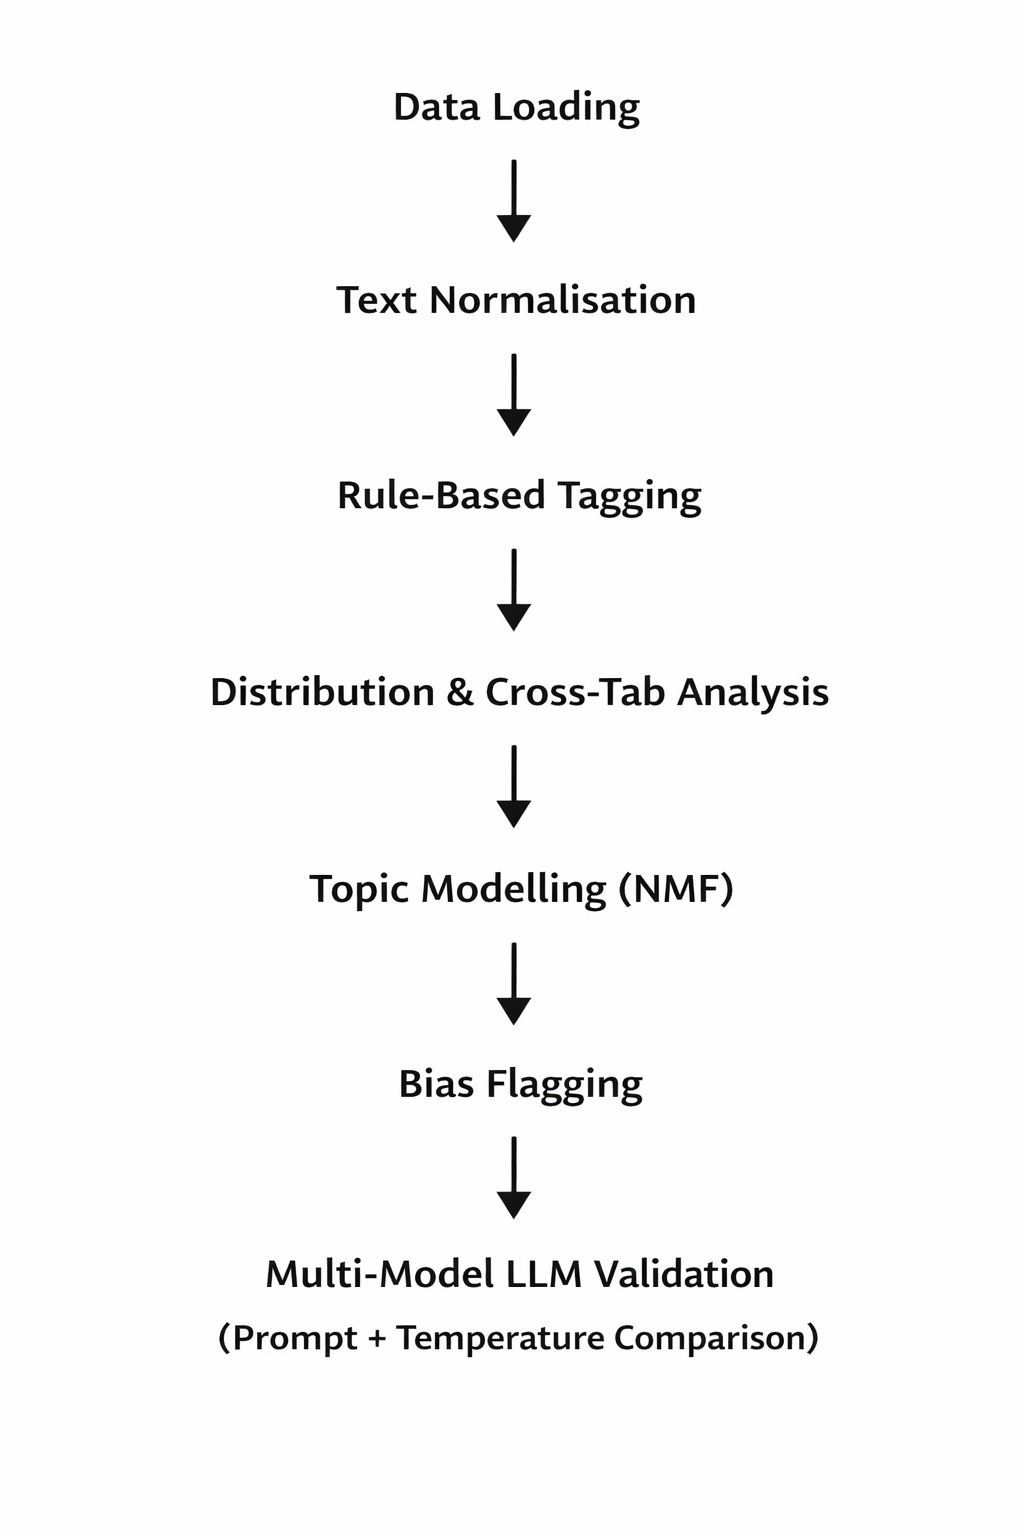

## Conclusion

- Implemented a **hybrid bias-auditing pipeline** combining rule-based tagging, statistical topic modelling (NMF), and LLM-based validation within Google Colab.

- Deterministic tagging provided a **fully reproducible and transparent baseline** for analysing gender, culture, theme, and role representation.

- Representation analysis indicated **moderate imbalance**, particularly in cultural specificity and subtle gender–role associations, though no extreme bias patterns were observed.

- Topic modelling validated dominant narrative clusters (e.g., adventure, justice, historical themes), strengthening the reliability of thematic categorisation.

- Comparative evaluation showed that **model choice, prompting strategy, and temperature settings significantly affect classification stability**.

- Structured role-based JSON prompting improved instruction adherence and consistency compared to baseline prompting.

- Lower temperature (0.2) produced **higher agreement and reproducibility**, whereas higher temperature (0.8) increased variability.

- The most stable configuration was **Gemini 1.5 Pro + structured JSON prompt + temperature 0.2**.

- Overall, the framework demonstrates a **scalable and responsible bias detection approach**, supporting ethical integration of story content into the interactive children’s storytelling application.